In [ ]:
# !pip install kagglehub

In [ ]:
# IMPORT STANDARD LIBRARIES

# Used for file and directory operations
import os

# Used for handling JSON files and data
import json

# Used for measuring execution time
import time

# Used for random number generation
import random

# Used to manage warning messages
import warnings


# IMPORT FILE HANDLING UTILITIES

# Provides an easier way to work with file paths
from pathlib import Path

# Used for counting class frequencies
from collections import Counter


# IMPORT DATA PROCESSING LIBRARIES

# Numerical computing library
import numpy as np

# Data analysis and dataframe handling
import pandas as pd


# IMPORT VISUALIZATION LIBRARY

# Used for plotting graphs and images
import matplotlib.pyplot as plt


# IMPORT IMAGE PROCESSING LIBRARY

# Used for opening and processing images
from PIL import Image


# IMPORT SCIKIT-LEARN UTILITIES

# Used for splitting dataset into train/test sets
from sklearn.model_selection import train_test_split

# Evaluation metrics for classification models
from sklearn.metrics import (
    accuracy_score,          # Overall accuracy
    precision_score,         # Precision metric
    recall_score,            # Recall metric
    f1_score,                # F1-score metric
    classification_report,  # Detailed performance report
    confusion_matrix,       # Confusion matrix
    ConfusionMatrixDisplay  # Visualization of confusion matrix
)


# IMPORT PYTORCH LIBRARIES

# Main PyTorch library
import torch

# Neural network components
import torch.nn as nn

# Optimization algorithms
import torch.optim as optim


# IMPORT DATASET AND DATALOADER UTILITIES

# Used for creating custom datasets and loading data
from torch.utils.data import Dataset, DataLoader


# IMPORT TORCHVISION UTILITIES

# Image transformations and pretrained models
from torchvision import transforms, models


# IMPORT PROGRESS BAR

# Displays training/testing progress bars
from tqdm.auto import tqdm


# IMPORT KAGGLE DATASET DOWNLOADER

# Used to download Kaggle datasets directly
import kagglehub


# IGNORE WARNING MESSAGES

warnings.filterwarnings("ignore")

In [ ]:
# SET RANDOM SEED FOR REPRODUCIBILITY

def set_seed(seed=42):

    # Set seed for Python random module
    random.seed(seed)

    # Set seed for NumPy operations
    np.random.seed(seed)

    # Set seed for PyTorch CPU operations
    torch.manual_seed(seed)

    # Set seed for all CUDA GPU operations
    torch.cuda.manual_seed_all(seed)


# Apply the seed value
set_seed(42)


# SET DEVICE (GPU IF AVAILABLE, OTHERWISE CPU)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# DISPLAY SYSTEM INFORMATION

# Print installed PyTorch version
print("PyTorch Version :", torch.__version__)

# Print selected device
print("Device :", DEVICE)


# DISPLAY GPU DETAILS IF CUDA IS AVAILABLE

if torch.cuda.is_available():

    # Print GPU name
    print("GPU :", torch.cuda.get_device_name(0))

PyTorch Version : 2.10.0+cu128
Device : cuda
GPU : Tesla T4


In [ ]:
# DOWNLOAD DATASET FROM KAGGLE

# Download the Plant Disease dataset
path = kagglehub.dataset_download("emmarex/plantdisease")


# DISPLAY DATASET LOCATION

print("Dataset Path:")
print(path)

100%|██████████| 658M/658M [00:10<00:00, 68.2MB/s]

Extracting files...


Dataset Path:
/root/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1


In [ ]:
# SET DATA DIRECTORY

# Define the main dataset folder path
DATA_DIR = Path(path) / "PlantVillage"


# CHECK IF DATASET EXISTS

print("Dataset Exists :", DATA_DIR.exists())


# GET ALL CLASS NAMES

# Collect folder names as class labels
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])


# DISPLAY DATASET INFORMATION

print("Number of Classes :", len(classes))

print("\nClass Names:\n")
print(classes)

Dataset Exists : True
Number of Classes : 15

Class Names:

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
# CREATE DATAFRAME FOR IMAGE PATHS AND LABELS

records = []


# LOOP THROUGH EACH CLASS FOLDER

for cls in classes:

    # Define class directory path
    cls_dir = DATA_DIR / cls

    # LOOP THROUGH ALL FILES IN THE CLASS DIRECTORY

    for file in cls_dir.iterdir():

        # CHECK FOR VALID IMAGE FILES

        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]:

            # STORE IMAGE PATH AND CLASS LABEL
            records.append({
                "filepath": str(file),
                "class_name": cls
            })


# CONVERT RECORDS INTO A DATAFRAME

df = pd.DataFrame(records)


# DISPLAY DATASET INFORMATION

print("Total Images :", len(df))


# SHOW FIRST 5 ROWS

df.head()

Total Images : 20638


,filepath,class_name
0,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot
1,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot
2,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot
3,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot
4,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot


In [ ]:
# CREATE LABEL ENCODING

# Convert class names into numerical labels
class_to_idx = {
    cls: idx
    for idx, cls in enumerate(sorted(df["class_name"].unique()))
}


# CREATE REVERSE LABEL MAPPING

# Convert numerical labels back to class names
idx_to_class = {
    idx: cls
    for cls, idx in class_to_idx.items()
}


# ADD LABEL COLUMN TO DATAFRAME

df["label"] = df["class_name"].map(class_to_idx)


# DISPLAY TOTAL NUMBER OF CLASSES

print("Total Classes :", len(class_to_idx))


# SHOW FIRST 5 ROWS

df.head()

Total Classes : 15


,filepath,class_name,label
0,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot,0
1,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot,0
2,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot,0
3,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot,0
4,/root/.cache/kagglehub/datasets/emmarex/plantd...,Pepper__bell___Bacterial_spot,0


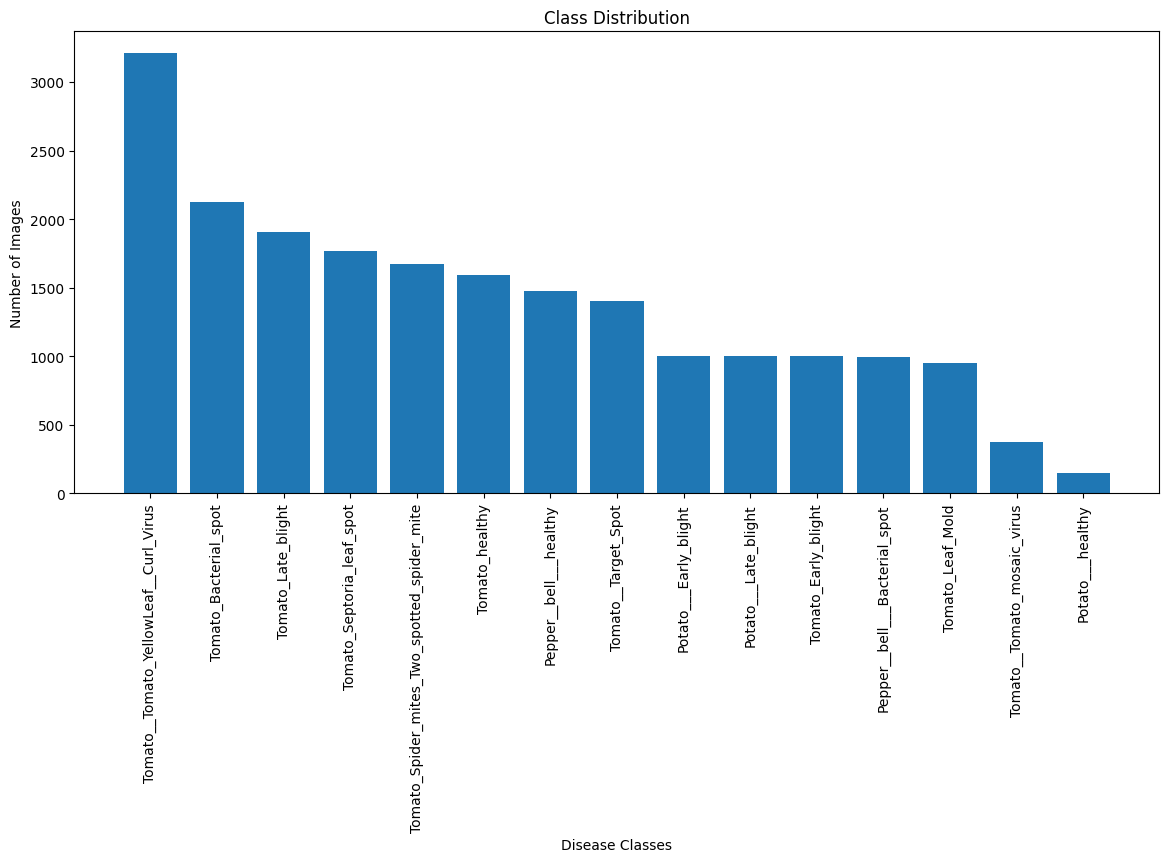

class_name
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1909
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato_healthy                                 1591
Pepper__bell___healthy                         1478
Tomato__Target_Spot                            1404
Potato___Early_blight                          1000
Potato___Late_blight                           1000
Tomato_Early_blight                            1000
Pepper__bell___Bacterial_spot                   997
Tomato_Leaf_Mold                                952
Tomato__Tomato_mosaic_virus                     373
Potato___healthy                                152
Name: count, dtype: int64


In [ ]:
# CHECK CLASS DISTRIBUTION

# Count number of images in each class
class_counts = df["class_name"].value_counts()


# CREATE BAR CHART

plt.figure(figsize=(14, 6))

# Plot class frequencies
plt.bar(class_counts.index, class_counts.values)


# ROTATE X-AXIS LABELS FOR BETTER READABILITY

plt.xticks(rotation=90)


# ADD CHART LABELS AND TITLE

plt.title("Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")


# DISPLAY PLOT

plt.show()


# DISPLAY CLASS COUNTS

print(class_counts)

In [ ]:
# ANALYZE SAMPLE IMAGES

# Randomly select 1000 images from the dataset
sample_df = df.sample(1000, random_state=42)


# STORE IMAGE PROPERTIES

widths = []
heights = []
modes = []


# LOOP THROUGH IMAGE FILES

for path in sample_df["filepath"]:

    # Open image
    image = Image.open(path)

    # Store image width
    widths.append(image.width)

    # Store image height
    heights.append(image.height)

    # Store image color mode (RGB, grayscale, etc.)
    modes.append(image.mode)


# DISPLAY IMAGE MODE COUNTS

print("Image Modes :", Counter(modes))


# DISPLAY WIDTH STATISTICS

print("\nWidth Statistics")
print(pd.Series(widths).describe())


# DISPLAY HEIGHT STATISTICS

print("\nHeight Statistics")
print(pd.Series(heights).describe())

Image Modes : Counter({'RGB': 999, 'RGBA': 1})

Width Statistics
count    1000.0
mean      256.0
std         0.0
min       256.0
25%       256.0
50%       256.0
75%       256.0
max       256.0
dtype: float64

Height Statistics
count    1000.0
mean      256.0
std         0.0
min       256.0
25%       256.0
50%       256.0
75%       256.0
max       256.0
dtype: float64


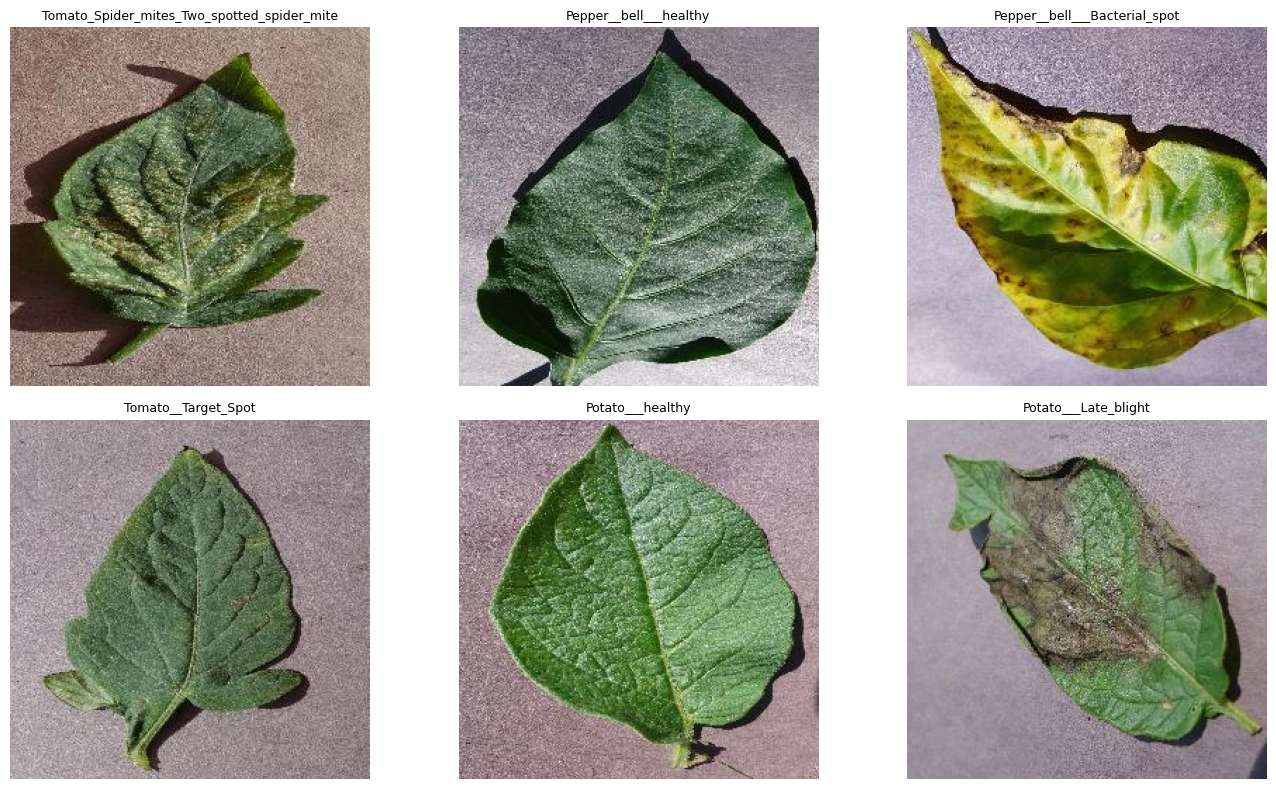

In [ ]:
# DISPLAY SAMPLE IMAGES FROM DIFFERENT CLASSES

# Randomly select 6 classes
sample_classes = random.sample(classes, 6)


# CREATE SUBPLOTS

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Flatten axes array for easier looping
axes = axes.flatten()


# LOOP THROUGH SELECTED CLASSES

for ax, cls in zip(axes, sample_classes):

    # Define class folder path
    cls_dir = DATA_DIR / cls

    # Get all JPG images
    images = list(cls_dir.glob("*.JPG"))

    # Check for lowercase jpg extension if needed
    if len(images) == 0:
        images = list(cls_dir.glob("*.jpg"))

    # Randomly select one image
    image_path = random.choice(images)

    # Open image and convert to RGB format
    image = Image.open(image_path).convert("RGB")


    # DISPLAY IMAGE

    ax.imshow(image)

    # Set image title as class name
    ax.set_title(cls, fontsize=9)

    # Hide axis values
    ax.axis("off")


# ADJUST LAYOUT

plt.tight_layout()

# DISPLAY FINAL PLOT
plt.show()

In [ ]:
# SPLIT DATA INTO TRAIN, VALIDATION, AND TEST SETS

# Split dataset into 70% training and 30% temporary data
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],   # Maintain class distribution
    random_state=42
)


# Split temporary data into validation and test sets
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],   # Maintain class distribution
    random_state=42
)


# DISPLAY DATASET SHAPES

print("Train Shape :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (14446, 3)
Validation Shape : (3096, 3)
Test Shape : (3096, 3)


In [ ]:
# IMAGE PARAMETERS

# Image size for model input
IMG_SIZE = 224

# Number of images per batch
BATCH_SIZE = 32


# TRAINING IMAGE TRANSFORMATIONS

train_transform = transforms.Compose([

    # Randomly crop and resize images
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    # Random horizontal flipping
    transforms.RandomHorizontalFlip(),

    # Random image rotation
    transforms.RandomRotation(10),

    # Random color adjustments
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize image using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# VALIDATION AND TEST TRANSFORMATIONS

val_test_transform = transforms.Compose([

    # Resize image to fixed dimensions
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize image using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# CREATE CUSTOM DATASET CLASS

class PlantDiseaseDataset(Dataset):

    # INITIALIZE DATASET

    def __init__(self, dataframe, transform=None):

        # Store dataframe and reset index
        self.dataframe = dataframe.reset_index(drop=True)

        # Store image transformations
        self.transform = transform


    # RETURN TOTAL NUMBER OF SAMPLES

    def __len__(self):

        return len(self.dataframe)


    # LOAD AND RETURN A SINGLE SAMPLE

    def __getitem__(self, idx):

        # Get row data using index
        row = self.dataframe.iloc[idx]


        # Load image and convert to RGB
        image = Image.open(row["filepath"]).convert("RGB")


        # Get image label
        label = int(row["label"])


        # Apply transformations if available
        if self.transform:
            image = self.transform(image)


        # Return processed image and label
        return image, label

In [ ]:
# CREATE DATASETS

# Training dataset with data augmentation
train_dataset = PlantDiseaseDataset(
    train_df,
    transform=train_transform
)

# Validation dataset
val_dataset = PlantDiseaseDataset(
    val_df,
    transform=val_test_transform
)

# Test dataset
test_dataset = PlantDiseaseDataset(
    test_df,
    transform=val_test_transform
)


# CREATE DATALOADERS

# Training dataloader with shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation dataloader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# DISPLAY DATASET SIZES

print("Train Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))
print("Test Samples :", len(test_dataset))

Train Samples : 14446
Validation Samples : 3096
Test Samples : 3096


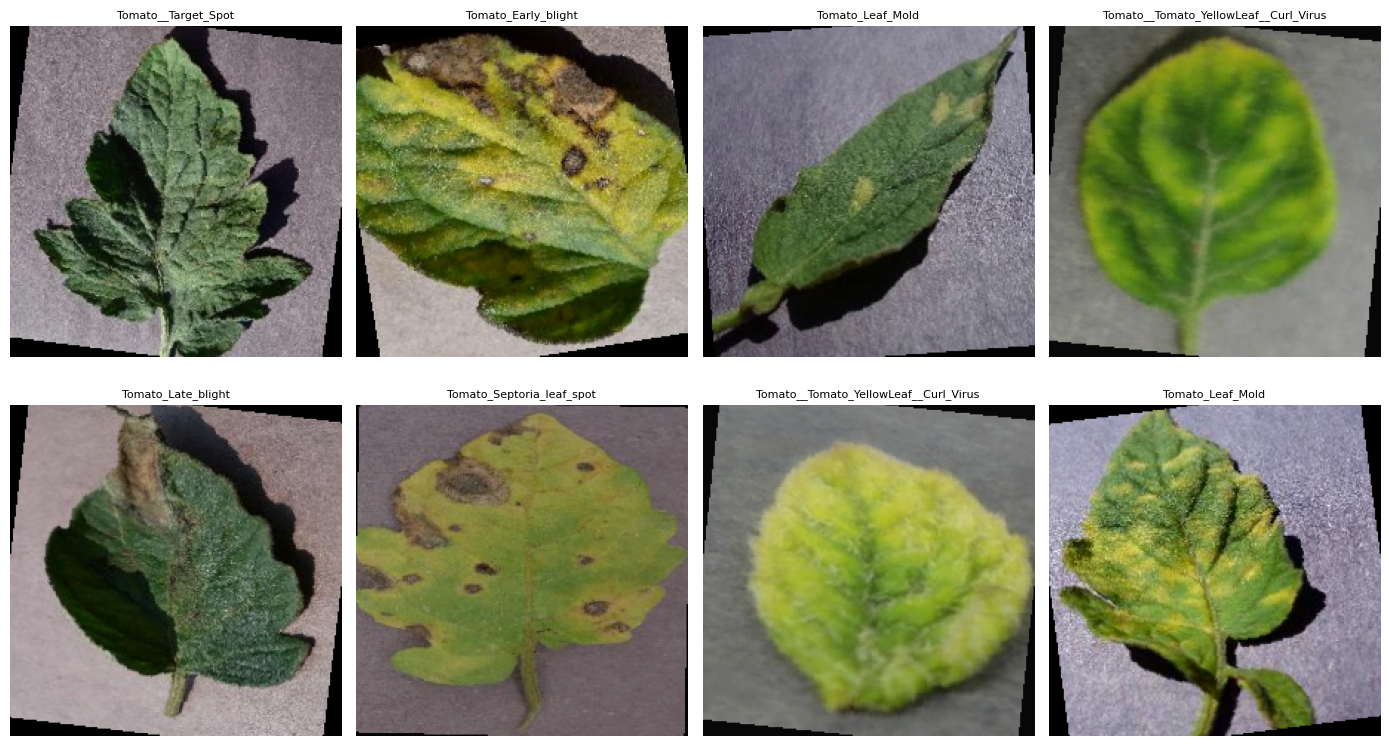

In [ ]:
# FUNCTION TO REVERSE NORMALIZATION

def unnormalize(img_tensor):

    # Create a copy of the tensor
    img = img_tensor.clone().detach()


    # Define ImageNet mean and standard deviation
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)


    # Reverse normalization
    img = img * std + mean


    # Keep pixel values between 0 and 1
    img = torch.clamp(img, 0, 1)

    return img


# LOAD A BATCH OF TRAINING IMAGES

images, labels = next(iter(train_loader))


# CREATE SUBPLOTS

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

# Flatten axes for easier iteration
axes = axes.flatten()


# DISPLAY AUGMENTED IMAGES

for i, ax in enumerate(axes):

    # Convert tensor image to NumPy format
    image = unnormalize(images[i]).permute(1,2,0).numpy()

    # Get class name from label
    label_name = idx_to_class[labels[i].item()]


    # Show image
    ax.imshow(image)

    # Set image title
    ax.set_title(label_name, fontsize=8)

    # Hide axis
    ax.axis("off")


# ADJUST LAYOUT AND DISPLAY PLOT

plt.tight_layout()
plt.show()

In [ ]:
# LOAD PRETRAINED MOBILENETV2 MODEL

model = models.mobilenet_v2(

    # Load pretrained ImageNet weights
    weights=models.MobileNet_V2_Weights.DEFAULT
)


# FREEZE FEATURE EXTRACTION LAYERS

# Prevent feature extractor weights from updating
for param in model.features.parameters():
    param.requires_grad = False


# MODIFY FINAL CLASSIFIER LAYER

# Get total number of output classes
num_classes = len(class_to_idx)

# Get input features of the original classifier
in_features = model.classifier[1].in_features


# Replace classifier with custom layers
model.classifier = nn.Sequential(

    # Dropout layer to reduce overfitting
    nn.Dropout(0.3),

    # Final fully connected layer
    nn.Linear(in_features, num_classes)
)


# MOVE MODEL TO DEVICE (GPU OR CPU)

model = model.to(DEVICE)


# DISPLAY MODEL ARCHITECTURE

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 135MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
# DEFINE LOSS FUNCTION

# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()


# DEFINE OPTIMIZER

optimizer = optim.AdamW(

    # Update only trainable parameters
    filter(lambda p: p.requires_grad, model.parameters()),

    # Learning rate
    lr=0.001
)


# DEFINE LEARNING RATE SCHEDULER

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    # Optimizer to adjust learning rate
    optimizer,

    # Monitor validation loss
    mode="min",

    # Reduce learning rate by this factor
    factor=0.5,

    # Wait for 2 epochs before reducing learning rate
    patience=2
)

In [ ]:
# FUNCTION FOR TRAINING AND VALIDATION

def run_epoch(model, loader, criterion, optimizer=None):

    # Check whether the model is in training mode
    is_train = optimizer is not None


    # Set model mode
    if is_train:
        model.train()
    else:
        model.eval()


    # Store total loss
    running_loss = 0.0

    # Store predictions and true labels
    all_preds = []
    all_labels = []


    # LOOP THROUGH DATA BATCHES

    for images, labels in tqdm(loader):

        # Move data to device
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)


        # Reset gradients during training
        if is_train:
            optimizer.zero_grad()


        # Enable gradients only during training
        with torch.set_grad_enabled(is_train):

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Get predicted class labels
            preds = outputs.argmax(dim=1)


            # BACKPROPAGATION

            if is_train:

                # Compute gradients
                loss.backward()

                # Update model weights
                optimizer.step()


        # Update running loss
        running_loss += loss.item() * images.size(0)


        # Store predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


    # CALCULATE EPOCH METRICS

    # Average loss
    epoch_loss = running_loss / len(loader.dataset)

    # Accuracy score
    epoch_acc = accuracy_score(all_labels, all_preds)

    # Macro F1-score
    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )


    return epoch_loss, epoch_acc, epoch_f1

In [ ]:
# MODEL TRAINING

# Number of training epochs
EPOCHS = 5


# Store training history
history = []


# Initialize best validation loss
best_val_loss = float("inf")


# TRAINING LOOP

for epoch in range(EPOCHS):

    # Record start time for the epoch
    start_time = time.time()


    # TRAINING PHASE

    train_loss, train_acc, train_f1 = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    # VALIDATION PHASE

    val_loss, val_acc, val_f1 = run_epoch(
        model,
        val_loader,
        criterion
    )


    # Update learning rate scheduler
    scheduler.step(val_loss)


    # STORE EPOCH RESULTS

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })


    # DISPLAY TRAINING RESULTS

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")


    # SAVE BEST MODEL

    if val_loss < best_val_loss:

        # Update best validation loss
        best_val_loss = val_loss


        # Save model weights
        torch.save(
            model.state_dict(),
            "best_mobilenetv2.pth"
        )

        print("Best Model Saved")

  0%|          | 0/452 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]


Epoch 1/5
Train Loss : 0.9752
Train Accuracy : 0.7592
Validation Loss : 0.4714
Validation Accuracy : 0.8911
Best Model Saved


  0%|          | 0/452 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

...

  0%|          | 0/97 [00:00<?, ?it/s]


Epoch 4/5
Train Loss : 0.3492
Train Accuracy : 0.8953
Validation Loss : 0.2355
Validation Accuracy : 0.9276
Best Model Saved


  0%|          | 0/452 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]


Epoch 5/5
Train Loss : 0.3173
Train Accuracy : 0.9029
Validation Loss : 0.2176
Validation Accuracy : 0.9428
Best Model Saved


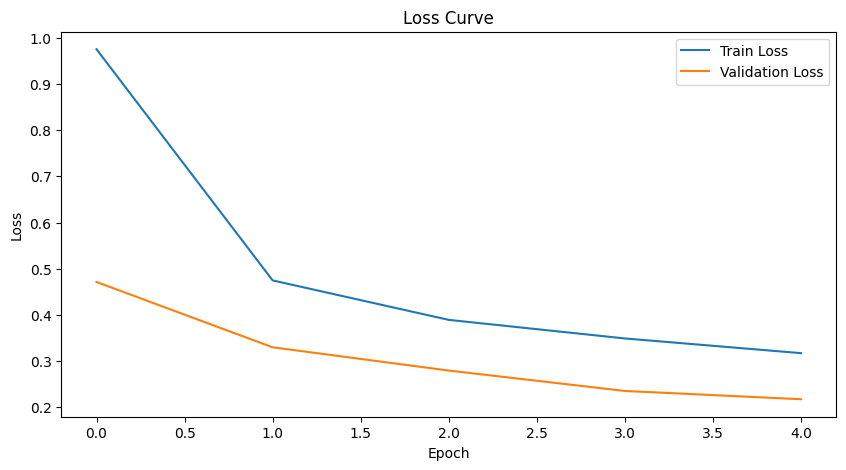

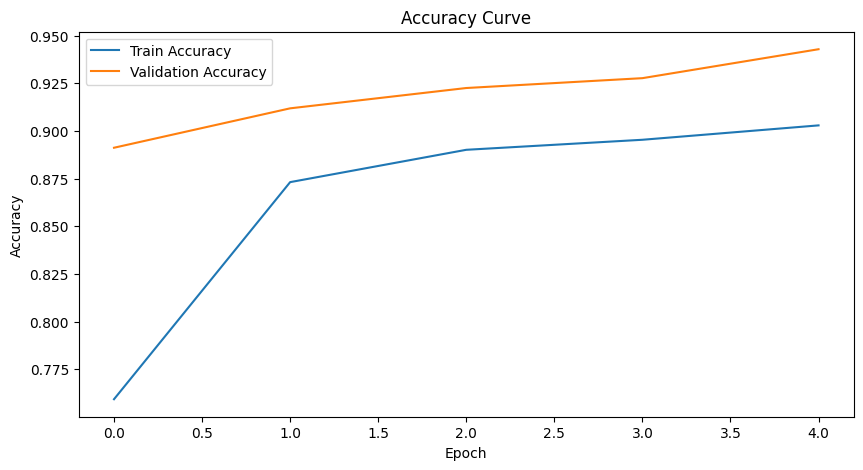

In [ ]:
# CREATE HISTORY DATAFRAME

# Convert training history into a dataframe
history_df = pd.DataFrame(history)


# PLOT LOSS CURVES

plt.figure(figsize=(10, 5))

# Training loss
plt.plot(history_df["train_loss"], label="Train Loss")

# Validation loss
plt.plot(history_df["val_loss"], label="Validation Loss")


# ADD TITLE AND LABELS

plt.title("Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")


# DISPLAY LEGEND

plt.legend()

# SHOW PLOT
plt.show()


# PLOT ACCURACY CURVES

plt.figure(figsize=(10, 5))

# Training accuracy
plt.plot(history_df["train_acc"], label="Train Accuracy")

# Validation accuracy
plt.plot(history_df["val_acc"], label="Validation Accuracy")


# ADD TITLE AND LABELS

plt.title("Accuracy Curve")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")


# DISPLAY LEGEND

plt.legend()

# SHOW PLOT
plt.show()

In [ ]:
# LOAD BEST SAVED MODEL

# Create MobileNetV2 architecture
best_model = models.mobilenet_v2(weights=None)


# GET INPUT FEATURES OF CLASSIFIER

in_features = best_model.classifier[1].in_features


# REPLACE FINAL CLASSIFIER LAYER

best_model.classifier = nn.Sequential(

    # Dropout layer for regularization
    nn.Dropout(0.3),

    # Final output layer
    nn.Linear(in_features, num_classes)
)


# LOAD SAVED MODEL WEIGHTS

best_model.load_state_dict(
    torch.load("best_mobilenetv2.pth")
)


# MOVE MODEL TO DEVICE

best_model = best_model.to(DEVICE)


# SET MODEL TO EVALUATION MODE

best_model.eval()


# DISPLAY STATUS MESSAGE

print("Best Model Loaded")

Best Model Loaded


In [ ]:
# EVALUATE MODEL ON TEST DATA

test_loss, test_acc, test_f1 = run_epoch(

    # Trained model
    best_model,

    # Test dataloader
    test_loader,

    # Loss function
    criterion
)


# DISPLAY TEST RESULTS

print("Test Loss :", round(test_loss, 4))

print("Test Accuracy :", round(test_acc, 4))

print("Test Macro F1 :", round(test_f1, 4))

  0%|          | 0/97 [00:00<?, ?it/s]

Test Loss : 0.2159
Test Accuracy : 0.9425
Test Macro F1 : 0.9366


In [ ]:
# GENERATE PREDICTIONS ON TEST DATA

all_preds = []
all_labels = []


# DISABLE GRADIENT CALCULATION

with torch.no_grad():

    # LOOP THROUGH TEST DATA

    for images, labels in tqdm(test_loader):

        # Move images to device
        images = images.to(DEVICE)


        # Forward pass
        outputs = best_model(images)


        # Get predicted class labels
        preds = outputs.argmax(dim=1)


        # Store predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


# GENERATE CLASSIFICATION REPORT

report = classification_report(

    # True labels
    all_labels,

    # Predicted labels
    all_preds,

    # Class names
    target_names=[
        idx_to_class[i]
        for i in range(num_classes)
    ]
)


# DISPLAY CLASSIFICATION REPORT

print(report)

  0%|          | 0/97 [00:00<?, ?it/s]

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.94      0.97      0.95       149
                     Pepper__bell___healthy       0.96      1.00      0.98       221
                      Potato___Early_blight       0.99      0.98      0.98       150
                       Potato___Late_blight       0.94      0.96      0.95       150
                           Potato___healthy       0.96      0.96      0.96        23
                      Tomato_Bacterial_spot       0.98      0.95      0.96       319
                        Tomato_Early_blight       0.86      0.75      0.80       150
                         Tomato_Late_blight       0.94      0.91      0.92       287
                           Tomato_Leaf_Mold       0.96      0.92      0.94       143
                  Tomato_Septoria_leaf_spot       0.90      0.97      0.93       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.90      0.94

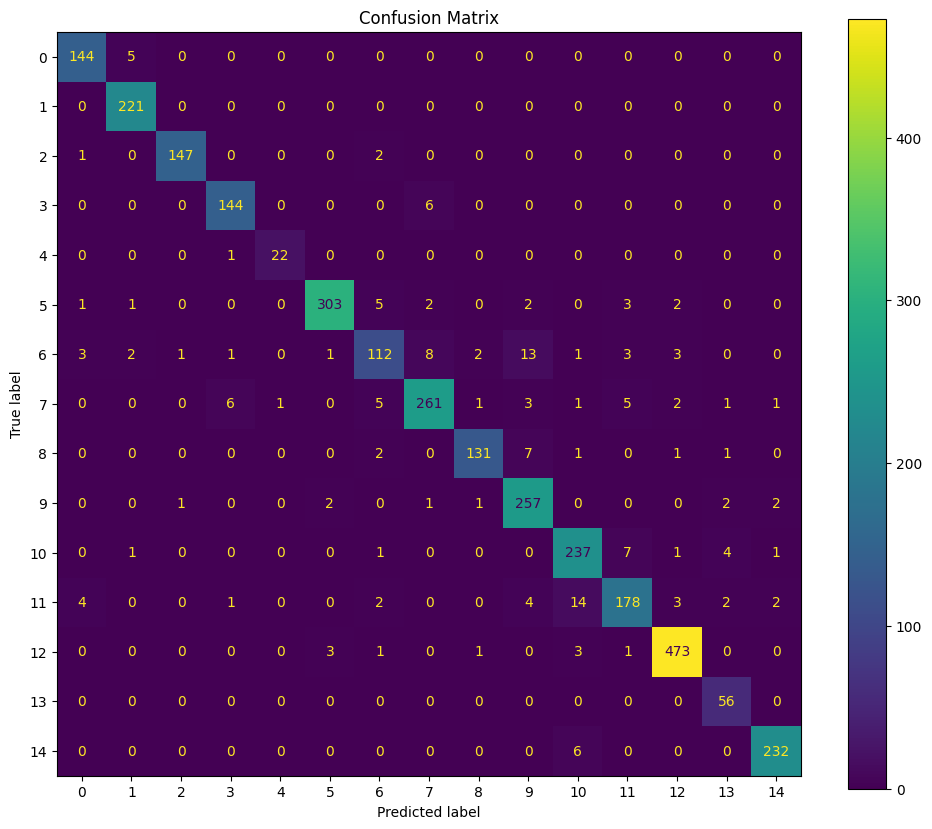

In [ ]:
# CREATE CONFUSION MATRIX

# Generate confusion matrix using true and predicted labels
cm = confusion_matrix(all_labels, all_preds)


# CREATE FIGURE

fig, ax = plt.subplots(figsize=(12, 10))


# DISPLAY CONFUSION MATRIX

disp = ConfusionMatrixDisplay(

    # Confusion matrix values
    confusion_matrix=cm
)

disp.plot(ax=ax)


# ADD TITLE

plt.title("Confusion Matrix")


# SHOW PLOT

plt.show()

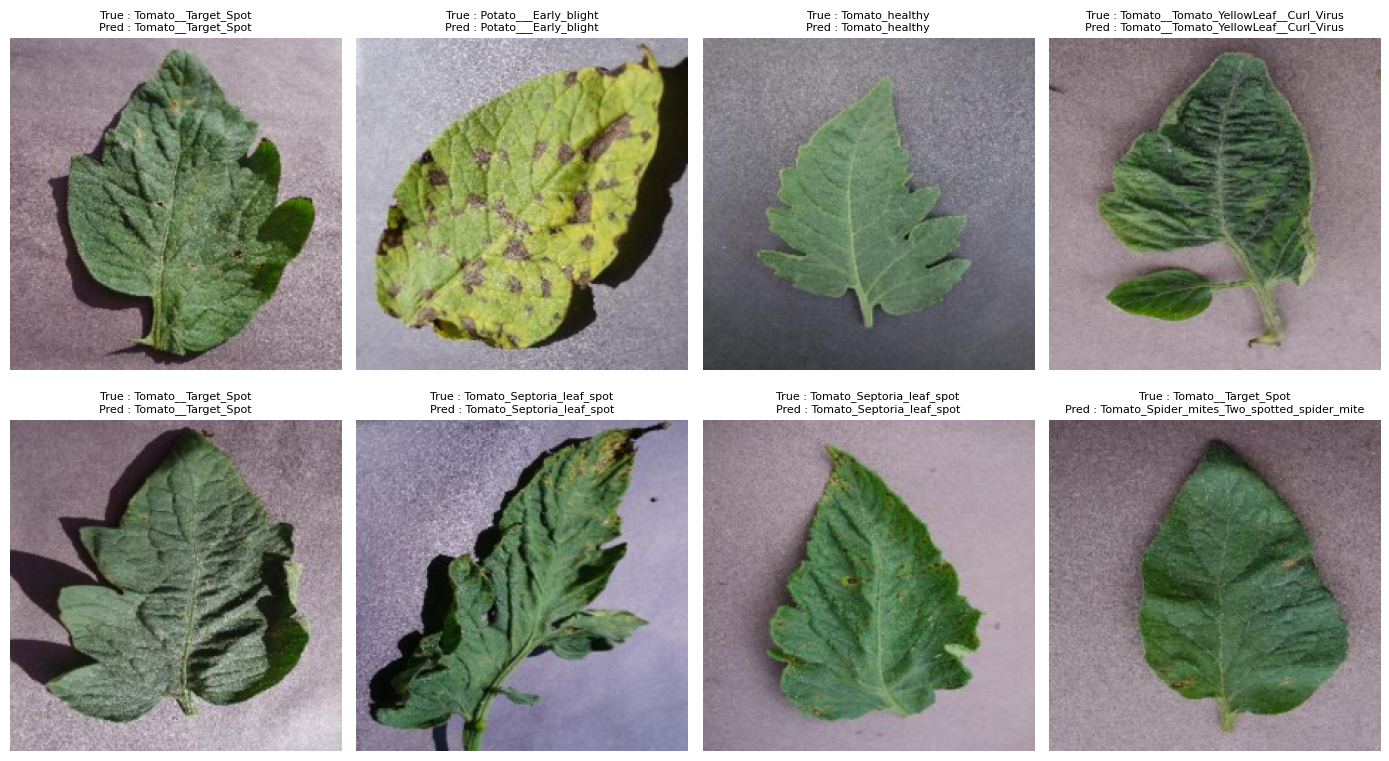

In [ ]:
# DISPLAY MODEL PREDICTIONS

# Load one batch from the test dataloader
images, labels = next(iter(test_loader))


# Move images to device
images_device = images.to(DEVICE)


# DISABLE GRADIENT CALCULATION

with torch.no_grad():

    # Generate model predictions
    outputs = best_model(images_device)

    # Get predicted class labels
    preds = outputs.argmax(dim=1).cpu()


# CREATE SUBPLOTS

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

# Flatten axes for easier iteration
axes = axes.flatten()


# DISPLAY IMAGES WITH PREDICTIONS

for i, ax in enumerate(axes):

    # Convert tensor image to NumPy format
    image = unnormalize(images[i]).permute(1,2,0).numpy()


    # Get true class label
    true_label = idx_to_class[labels[i].item()]

    # Get predicted class label
    pred_label = idx_to_class[preds[i].item()]


    # Display image
    ax.imshow(image)


    # Add true and predicted labels
    ax.set_title(
        f"True : {true_label}\nPred : {pred_label}",
        fontsize=8
    )


    # Hide axis
    ax.axis("off")


# ADJUST LAYOUT

plt.tight_layout()


# SHOW PLOT

plt.show()

In [ ]:
# SAVE FINAL MODEL

torch.save(
    best_model.state_dict(),
    "final_mobilenetv2_model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully
